In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [115]:
df = pd.read_csv('Kickstarter.csv')

In [116]:
df.head(5)

,backers_count,blurb,category,converted_pledged_amount,country,country_displayable_name,created_at,creator,currency,currency_symbol,...,spotlight,staff_pick,state,state_changed_at,static_usd_rate,urls,usd_exchange_rate,usd_pledged,usd_type,video
0,2,"Nature's Bounty Farm, Inc is a non profit orga...","{""id"":305,""name"":""Community Gardens"",""analytic...",65.0,US,the United States,1477586619,"{""id"":1511805759,""name"":""Tabatha Tasker"",""is_r...",USD,$,...,False,False,failed,1480959781,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,65.0,domestic,"{""id"":720778,""status"":""successful"",""hls"":null,..."
1,2,Ubuntu Cultivators is dedicated to growing yea...,"{""id"":305,""name"":""Community Gardens"",""analytic...",101.0,US,the United States,1474041806,"{""id"":1676618956,""name"":""Hannah Kiraly"",""is_re...",USD,$,...,False,False,failed,1479492461,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,101.0,domestic,NaN
2,12,He accidentally got her fired. Then he stole h...,"{""id"":47,""name"":""Fiction"",""analytics_name"":""Fi...",222.0,US,the United States,1735658350,"{""id"":529770689,""name"":""Kathryn Kaleigh"",""slug...",USD,$,...,False,False,live,1736267868,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,222.0,domestic,NaN
3,40,"Printing Chapters 1-2 of my webcomic, Lanterns...","{""id"":253,""name"":""Webcomics"",""analytics_name"":...",1217.0,US,the United States,1565130202,"{""id"":1425061218,""name"":""spaceturtleart"",""slug...",USD,$,...,False,False,failed,1570120062,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,1217.0,domestic,"{""id"":982781,""status"":""successful"",""hls"":""http..."
4,4,Scoffer Studios Productions is an indie studio...,"{""id"":253,""name"":""Webcomics"",""analytics_name"":...",42.0,US,the United States,1557876684,"{""id"":515139000,""name"":""Gov Scoffer"",""is_regis...",USD,$,...,False,False,failed,1561862339,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,42.0,domestic,NaN


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3194 entries, 0 to 3193
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   backers_count                       3194 non-null   int64  
 1   blurb                               3194 non-null   object 
 2   category                            3194 non-null   object 
 3   converted_pledged_amount            2969 non-null   float64
 4   country                             3194 non-null   object 
 5   country_displayable_name            3194 non-null   object 
 6   created_at                          3194 non-null   int64  
 7   creator                             3194 non-null   object 
 8   currency                            3194 non-null   object 
 9   currency_symbol                     3194 non-null   object 
 10  currency_trailing_code              3194 non-null   bool   
 11  current_currency                    3194 no

In [118]:
df.isnull().sum()

backers_count                            0
blurb                                    0
category                                 0
converted_pledged_amount               225
country                                  0
country_displayable_name                 0
created_at                               0
creator                                  0
currency                                 0
currency_symbol                          0
currency_trailing_code                   0
current_currency                         0
deadline                                 0
disable_communication                    0
fx_rate                                  0
goal                                     0
id                                       0
is_disliked                              0
is_in_post_campaign_pledging_phase    2507
is_launched                              0
is_liked                                 0
is_starrable                             0
launched_at                              0
location   

In [119]:
df.describe()

,backers_count,converted_pledged_amount,created_at,deadline,fx_rate,goal,id,launched_at,percent_funded,pledged,state_changed_at,static_usd_rate,usd_exchange_rate,usd_pledged
count,3194.000000,2.969000e+03,3.194000e+03,3.194000e+03,3194.000000,3.194000e+03,3.194000e+03,3.194000e+03,3194.000000,3.194000e+03,3.194000e+03,3194.000000,2969.000000,2.969000e+03
mean,148.349405,1.865339e+04,1.556426e+09,1.453696e+09,0.954701,6.843939e+04,1.066501e+09,1.441895e+09,388.711733,4.309142e+04,1.563891e+09,0.921448,0.990176,1.864519e+04
std,723.179880,1.398456e+05,1.204593e+08,4.005364e+08,0.241857,1.553767e+06,6.184334e+08,4.130994e+08,7536.203488,8.148904e+05,1.202216e+08,0.361968,0.266689,1.398269e+05
min,0.000000,0.000000e+00,1.251832e+09,0.000000e+00,0.006347,0.000000e+00,1.009485e+06,0.000000e+00,0.000000,0.000000e+00,1.257656e+09,0.000000,0.006499,0.000000e+00
25%,3.000000,2.010000e+02,1.456213e+09,1.436398e+09,1.000000,1.000000e+03,5.266453e+08,1.431579e+09,1.207750,8.400000e+01,1.461876e+09,1.000000,1.000000,2.010000e+02
50%,24.000000,1.866000e+03,1.557897e+09,1.535805e+09,1.000000,4.000000e+03,1.057195e+09,1.530799e+09,102.220757,1.525500e+03,1.565987e+09,1.000000,1.000000,1.886594e+03
75%,82.750000,7.529000e+03,1.666605e+09,1.656714e+09,1.000000,1.189825e+04,1.592956e+09,1.652196e+09,134.468750,7.283750e+03,1.672598e+09,1.000000,1.000000,7.490357e+03
max,17402.000000,5.394102e+06,1.736633e+09,1.741751e+09,1.213899,7.000000e+07,2.147343e+09,1.736571e+09,417800.000000,4.462657e+07,1.736652e+09,1.713972,1.713652,5.394102e+06


In [120]:
df = df.drop_duplicates()

In [121]:
df = df.dropna(subset=['goal', 'pledged', 'state'])

In [122]:
df['launched_at'] = pd.to_datetime(df['launched_at'],  unit='s', errors='coerce')
df['deadline'] = pd.to_datetime(df['deadline'], unit='s', errors='coerce')
df['created_at'] = pd.to_datetime(df['created_at'], unit='s', errors='coerce')
df['state_changed_at'] = pd.to_datetime(df['state_changed_at'], unit='s', errors='coerce')

In [123]:
df.head()

,backers_count,blurb,category,converted_pledged_amount,country,country_displayable_name,created_at,creator,currency,currency_symbol,...,spotlight,staff_pick,state,state_changed_at,static_usd_rate,urls,usd_exchange_rate,usd_pledged,usd_type,video
0,2,"Nature's Bounty Farm, Inc is a non profit orga...","{""id"":305,""name"":""Community Gardens"",""analytic...",65.0,US,the United States,2016-10-27 16:43:39,"{""id"":1511805759,""name"":""Tabatha Tasker"",""is_r...",USD,$,...,False,False,failed,2016-12-05 17:43:01,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,65.0,domestic,"{""id"":720778,""status"":""successful"",""hls"":null,..."
1,2,Ubuntu Cultivators is dedicated to growing yea...,"{""id"":305,""name"":""Community Gardens"",""analytic...",101.0,US,the United States,2016-09-16 16:03:26,"{""id"":1676618956,""name"":""Hannah Kiraly"",""is_re...",USD,$,...,False,False,failed,2016-11-18 18:07:41,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,101.0,domestic,NaN
2,12,He accidentally got her fired. Then he stole h...,"{""id"":47,""name"":""Fiction"",""analytics_name"":""Fi...",222.0,US,the United States,2024-12-31 15:19:10,"{""id"":529770689,""name"":""Kathryn Kaleigh"",""slug...",USD,$,...,False,False,live,2025-01-07 16:37:48,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,222.0,domestic,NaN
3,40,"Printing Chapters 1-2 of my webcomic, Lanterns...","{""id"":253,""name"":""Webcomics"",""analytics_name"":...",1217.0,US,the United States,2019-08-06 22:23:22,"{""id"":1425061218,""name"":""spaceturtleart"",""slug...",USD,$,...,False,False,failed,2019-10-03 16:27:42,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,1217.0,domestic,"{""id"":982781,""status"":""successful"",""hls"":""http..."
4,4,Scoffer Studios Productions is an indie studio...,"{""id"":253,""name"":""Webcomics"",""analytics_name"":...",42.0,US,the United States,2019-05-14 23:31:24,"{""id"":515139000,""name"":""Gov Scoffer"",""is_regis...",USD,$,...,False,False,failed,2019-06-30 02:38:59,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,42.0,domestic,NaN


In [124]:
df = df[df['state'].isin(['successful', 'failed'])]

In [136]:
df['duration_days'] = ((df['deadline'] - df['launched_at']).dt.total_seconds() / 86400).round()
df['duration_days'][:5]

0    31.0
1    60.0
3    30.0
4    40.0
5    30.0
Name: duration_days, dtype: float64

In [126]:
df['is_successful'] = df['state'].apply(lambda x: 1 if x == 'successful' else 0)
df['is_successful'][:5]

0    0
1    0
3    0
4    0
5    0
Name: is_successful, dtype: int64

In [127]:
df['funding_ratio'] = df['pledged'] / df['goal']
df['funding_ratio'][:5]

0    0.000433
1    0.010100
3    0.093615
4    0.420000
5    0.160000
Name: funding_ratio, dtype: float64

In [128]:
# Success Rate
df['state'].value_counts(normalize=True)

state
successful    0.666306
failed        0.333694
Name: proportion, dtype: float64

In [129]:
def extract_category (x):
    try:
        return json.loads(x)['name']
    except:
        return None
df['main_category'] = df['category'].apply(extract_category)

In [130]:
category_count = df['main_category'].value_counts()
valid_categories = category_count[category_count > 50].index
df_filtered = df[df['main_category'].isin(valid_categories)]

In [131]:
# Success by category
df_filtered.groupby('main_category')['is_successful'].mean().sort_values(ascending=False)

main_category
Accessories         1.000000
Art Books           1.000000
Comic Books         1.000000
Drama               1.000000
Gadgets             1.000000
Hardware            1.000000
Indie Rock          1.000000
Mixed Media         1.000000
Radio & Podcasts    0.531915
Stationery          0.482143
Ready-to-wear       0.460317
Small Batch         0.139535
Web                 0.084211
Name: is_successful, dtype: float64

In [132]:
df = df[df['goal'] > 0]
df = df[df['pledged'] >= 0]
df = df[df['goal'] < df['goal'].quantile(0.99)]

In [145]:
df.groupby(pd.qcut(df['goal'], q=5, duplicates = 'drop'))['is_successful'].mean()

C:\Users\Amera\AppData\Local\Temp\ipykernel_17824\3258362989.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['goal'], q=5, duplicates = 'drop'))['is_successful'].mean()


goal
(0.999, 1000.0]        0.793600
(1000.0, 3000.0]       0.723757
(3000.0, 6285.0]       0.708245
(6285.0, 15000.0]      0.628319
(15000.0, 278500.0]    0.483932
Name: is_successful, dtype: float64

In [146]:
df.groupby(pd.qcut(df['duration_days'], q=5, duplicates = 'drop'))['is_successful'].mean()

C:\Users\Amera\AppData\Local\Temp\ipykernel_17824\3345923849.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['duration_days'], q=5, duplicates = 'drop'))['is_successful'].mean()


duration_days
(0.999, 27.0]    0.797101
(27.0, 30.0]     0.651925
(30.0, 43.0]     0.737470
(43.0, 90.0]     0.534070
Name: is_successful, dtype: float64

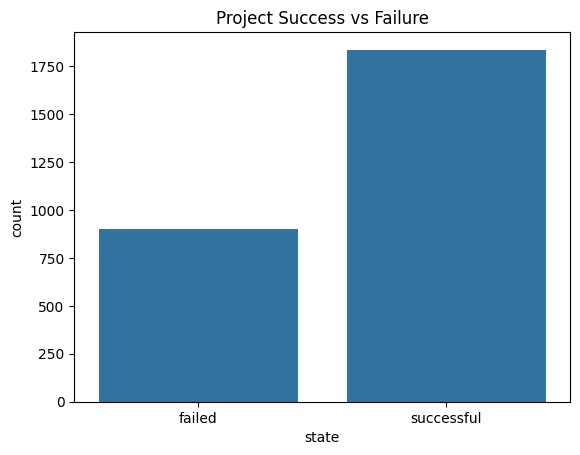

In [138]:
sns.countplot(x='state', data=df)
plt.title("Project Success vs Failure")
plt.show()

In [148]:
country_success = df.groupby('country')['is_successful'].mean().sort_values(ascending=False)

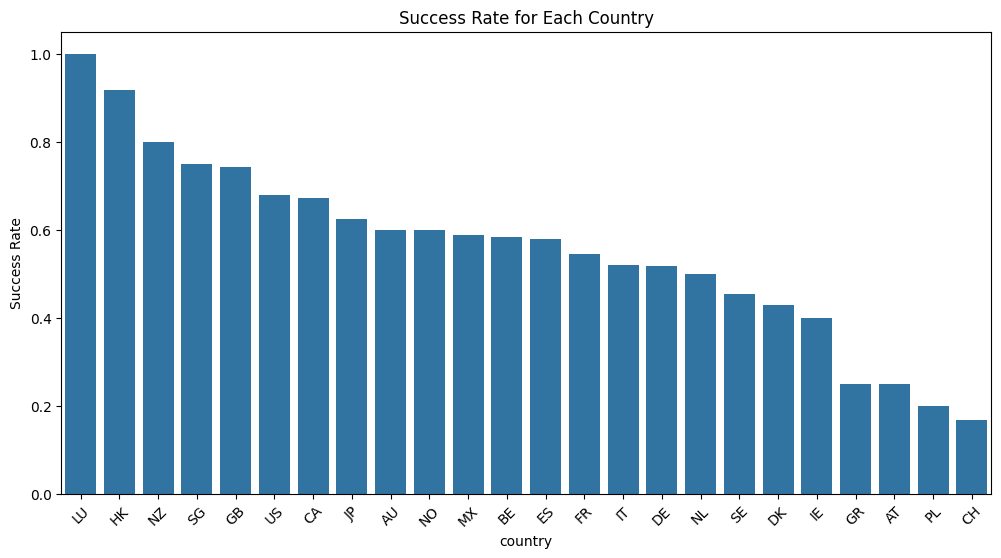

In [150]:
plt.figure(figsize = (12, 6))
sns.barplot(x = country_success.index, y = country_success.values)
plt.xticks(rotation = 45)
plt.ylabel('Success Rate')
plt.title('Success Rate for Each Country')
plt.show()

In [158]:
# خد top 10 categories by total number of campaigns
top_categories = df['main_category'].value_counts().nlargest(10).index
df_top = df[df['main_category'].isin(top_categories)]

In [159]:
top_countries = df['country'].value_counts().nlargest(10).index
df_top = df_top[df_top['country'].isin(top_countries)]

<Axes: xlabel='country', ylabel='main_category'>

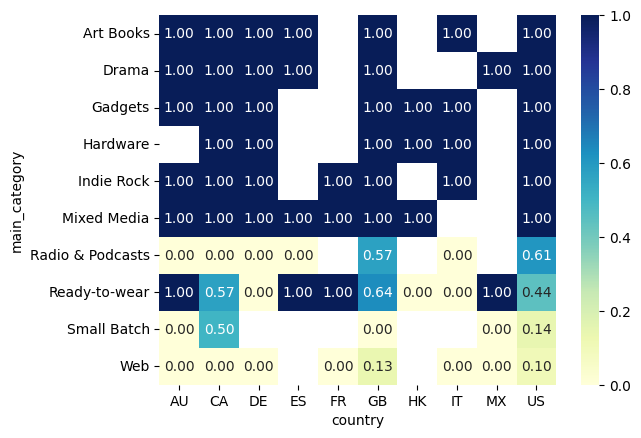

In [160]:
pivot = df_top.pivot_table(index='main_category', columns='country', values='is_successful', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')

In [157]:
category_country_max_funding = df.groupby(['country', 'main_category'])['pledged'].max().reset_index()
category_country_max_funding.sort_values(by=['pledged', 'main_category'], ascending=False)

,country,main_category,pledged
518,US,Hardware,5394102.0
312,HK,Hardware,3288056.0
554,US,Ready-to-wear,3127299.5
320,HK,Sound,2683242.0
367,JP,Apparel,2500309.0
...,...,...,...
383,MX,Food Trucks,0.0
407,NL,Food Trucks,0.0
405,NL,DIY,0.0
1,AT,Camera Equipment,0.0
